# Simulations

In [1]:
import sys
sys.path.insert(0, 'LOCAT01_PATH')

# If the old locat package was already imported in this kernel, clear it.
for mod in list(sys.modules):
    if mod == 'locat' or mod.startswith('locat.'):
        del sys.modules[mod]


In [2]:
from numpy import random
import numpy as np

In [3]:
import os

In [4]:
!nvidia-smi

Tue Mar 17 16:40:15 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.56.06    Driver Version: 525.125.06   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A6000    Off  | 00000000:01:00.0 Off |                  Off |
| 30%   26C    P8    10W / 300W |  45422MiB / 49140MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A6000    Off  | 00000000:24:00.0 Off |                  Off |
| 30%   

In [5]:
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
SEED = 13

def reset_seeds(seed=SEED):
    np.random.seed(seed)
    return seed

reset_seeds(SEED)


13

In [6]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from sklearn.datasets import make_blobs

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

In [7]:
def create_anndata(matrix, cell_names=None, gene_names=None):
    adata = ad.AnnData(matrix)
    adata.obs_names = cell_names or [f"Cell_{i}" for i in range(adata.n_obs)]
    adata.var_names = gene_names or [f"Gene_{i}" for i in range(adata.n_vars)]
    return adata

In [8]:
from sklearn.metrics import roc_curve

In [9]:
from locat.locat import LOCAT


In [10]:
# create the baseline data
sds = [1.0, ] #0.3, 0.1]
coords, clusts, centers = make_blobs(n_samples=[5000, ], n_features=2, centers=None, return_centers=True, random_state=0, cluster_std=sds)

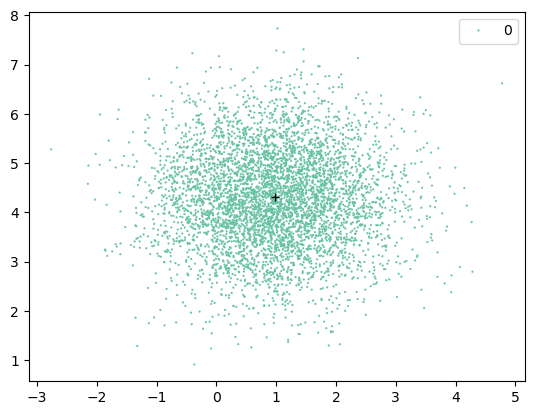

In [11]:
sns.scatterplot(
    x=coords[:,0], 
    y=coords[:,1],
    hue=clusts,
    s=2,
    palette='Set2',
    edgecolor=None)
for xc in centers:
    plt.plot(xc[0], xc[1], 'k+')

# Dispersion around the background peak

In [58]:
reset_seeds(SEED)
# power

n = 25
n_tests = 200
radii = 10**np.linspace(np.log10(0.3), np.log10(3), n_tests)

genes = np.zeros(shape=(coords.shape[0], n_tests))
for i, s in enumerate(radii):
    i_sel = np.flatnonzero( np.sqrt(np.sum((coords - centers[0,:])**2, axis=1)) < s )
    if len(i_sel)>=n:
        i_genes = np.random.choice(i_sel, n, replace=False)
        genes[i_genes, i] = 1
    else:
        print(i, s, len(i_sel))

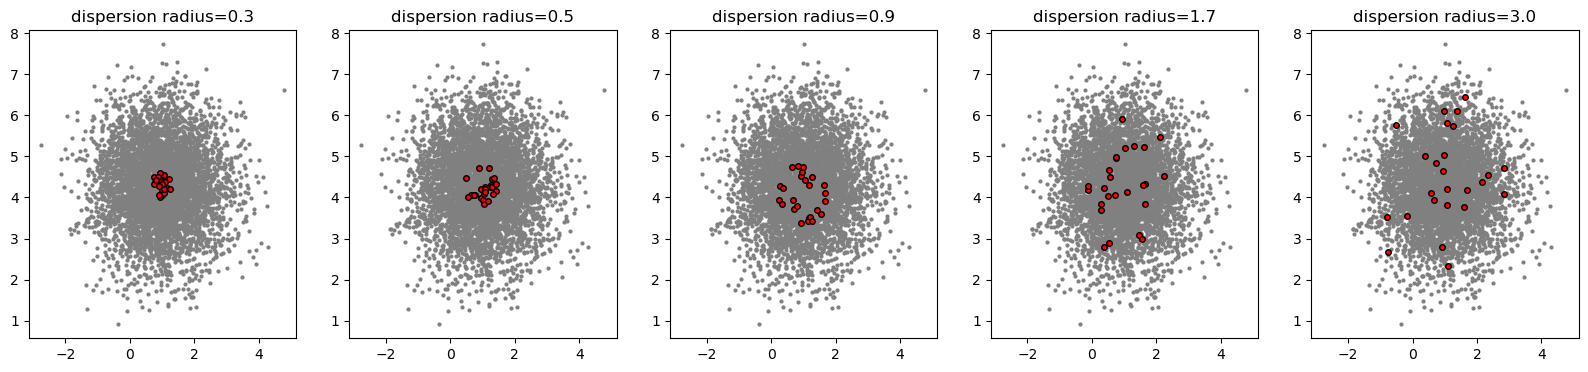

In [59]:
plt.figure(figsize=(20, 4))
i_plots = np.floor(np.linspace(0, n_tests-1, 5)).astype(int)
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.plot(coords[:,0], coords[:,1], '.', markersize=4, color='gray')
    #sns.kdeplot(x=coords[:,0], y=coords[:,1], levels=7, color='k')
    plt.plot(coords[genes[:,i_plots[i]]>0,0], 
             coords[genes[:,i_plots[i]]>0,1], 
             'o',
             markersize=4,
             markerfacecolor='r', 
             markeredgecolor='k')
    plt.title(f'dispersion radius={radii[i_plots[i]]:.1f}')
plt.show()
    

In [60]:
adata = create_anndata(genes.astype(np.float64))

In [61]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)

/home/wes/.conda/envs/mulde_jax/lib/python3.10/site-packages/scipy/sparse/_index.py:145: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


In [62]:
adata.obsp["connectivities"]

<5000x5000 sparse matrix of type '<class 'numpy.float32'>'
	with 121062 stored elements in Compressed Sparse Row format>

In [63]:
reset_seeds(SEED)
m = LOCAT(create_anndata(genes.astype(np.float64)), coords.astype(np.float64), 20, show_progress=True, n_bootstrap_inits=20, knn=adata.obsp["connectivities"])
#m.background_pdf(total_counts_weight=False, force_refresh=True)

In [64]:
#m.gmm_local_scan(zscore_thresh=-np.inf, max_freq=1.)

In [65]:
%%time
reset_seeds(SEED)
m = LOCAT(create_anndata(genes.astype(np.float64)), coords.astype(np.float64), 20, show_progress=True, n_bootstrap_inits=100, knn=adata.obsp["connectivities"])
m.background_pdf(force_refresh=True)

sres = {
    'full': m.gmm_scan(
        zscore_thresh=-np.inf,
        max_freq=1.0,
        rc_lambda_values=np.linspace(1.0, 2.0, 8),
        include_depletion_scan=True,
    ),
    'local': m.gmm_local_scan(zscore_thresh=-np.inf, max_freq=1.0),
    'llr': m.gmm_loglikelihoodtest(max_freq=1.0),
    'lpval': m.gmm_local_pvalue(),
}

locat_df = pd.DataFrame({gene: res._asdict() for gene, res in sres["full"].items()}).T
locat_df.index.name = "gene"


2026-03-17 18:00:08.567 | INFO     | locat.locat:background_pdf:427 - fitting background PDF
2026-03-17 18:00:08.568 | INFO     | locat.locat:background_n_components_init:197 - Estimating number of GMM components
estimating BIC for 5000 cells:   0%|                                           | 0/9 [00:00<?, ?it/s]2026-03-17 18:00:08.571 | INFO     | locat.locat:min_dist:135 - recomputing min cell-cell distance
2026-03-17 18:00:08.571 | INFO     | locat.locat:cell_dist:127 - recomputing cell-cell distance
estimating BIC for 70 cells: 100%|███████████████████████████████████| 30/30 [00:00<00:00, 71.51it/s]
2026-03-17 18:00:11.251 | INFO     | locat.locat:background_pdf:439 - Using 1 components
fitting background: 100%|████████████████████████████████████████████| 10/10 [00:00<00:00, 73.23it/s]
null distribution parameters (perm. pseudo-genes): 100%|███████████████| 7/7 [00:31<00:00,  4.55s/it]
scanning genes: 100%|██████████████████████████████████████████████| 200/200 [03:24<00:00,  1.02

CPU times: user 20min 49s, sys: 1h 11min 1s, total: 1h 31min 51s
Wall time: 4min 13s


In [66]:
# LOCAT native p-values are used directly via locat_df["pval"] in this repro notebook.


In [67]:
#locat_df.sort_values(by="pval",ascending=False)["depletion_scan"][0]

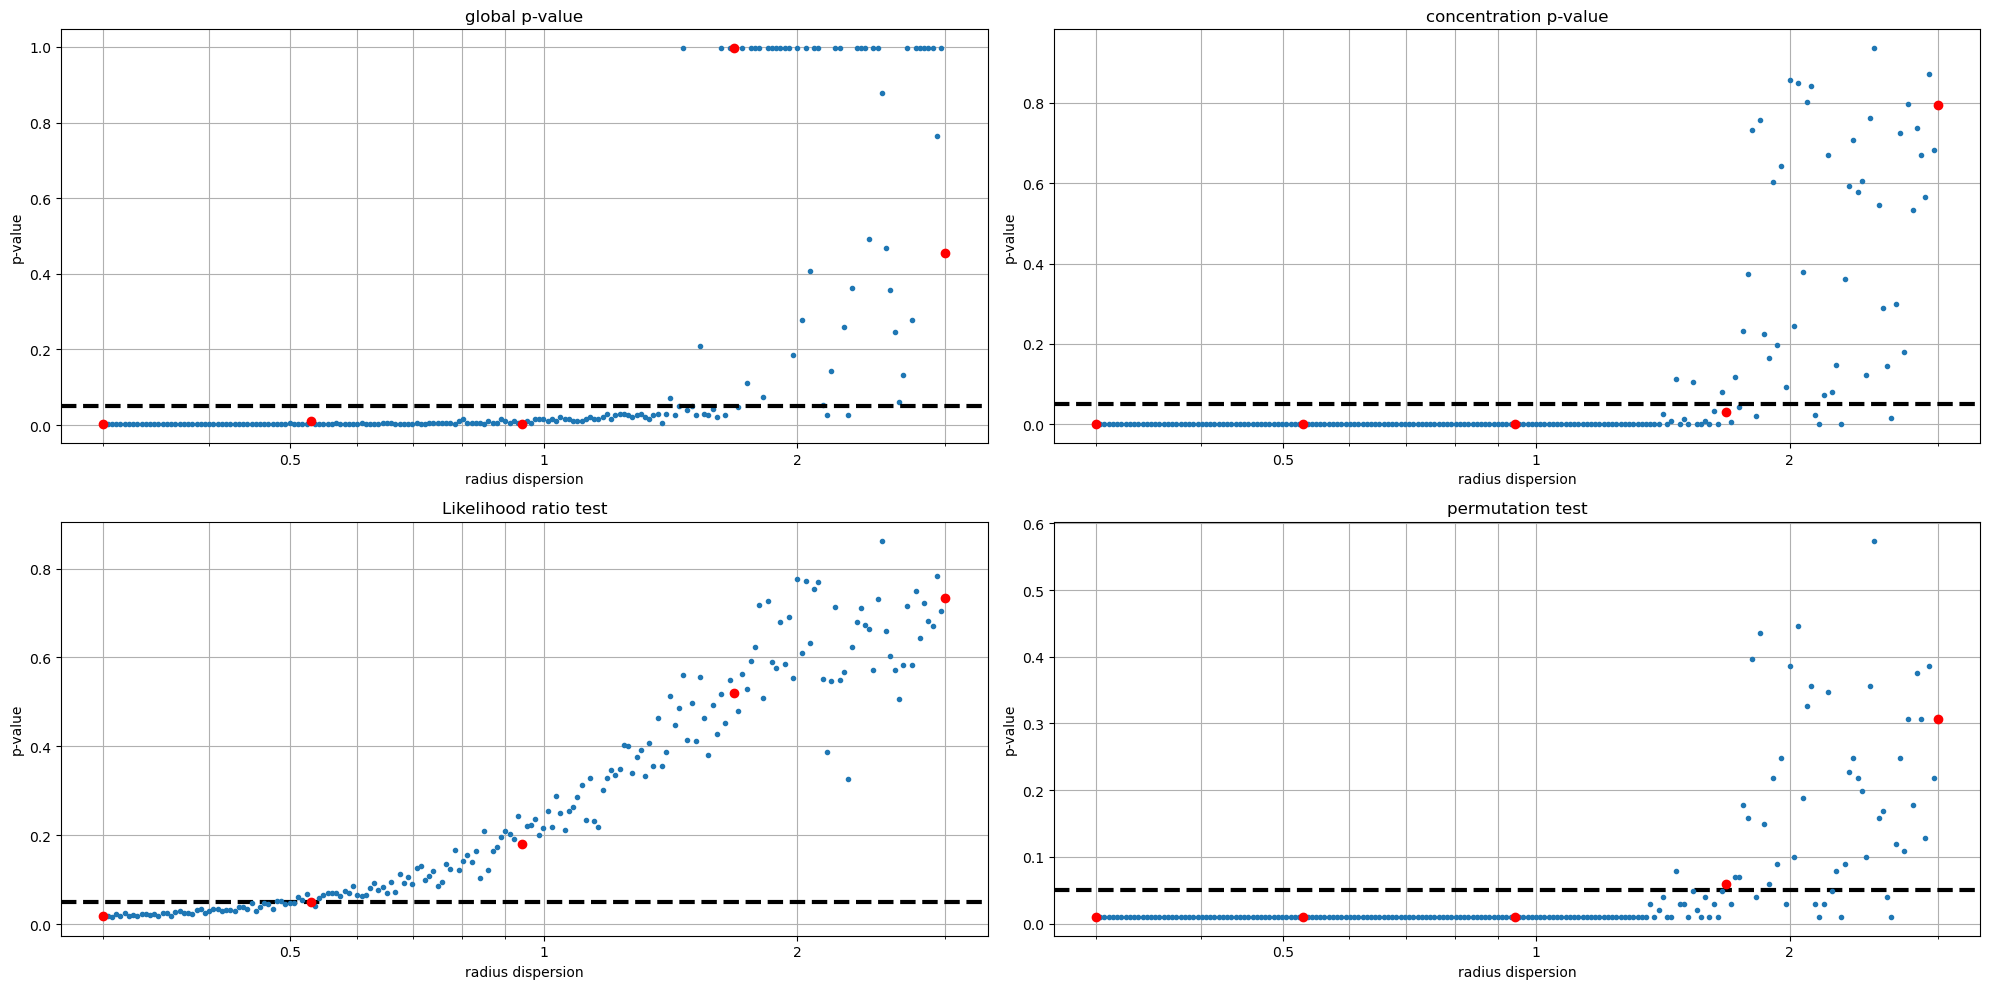

In [69]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

plt.figure(figsize=(20, 10))

plt.subplot(221)
plt.plot(radii, locat_df['pval'].values, '.')
plt.plot(radii[i_plots], locat_df['pval'].values[i_plots], 'ro')
plt.gca().set_xscale('log')
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.ylabel('p-value')
plt.xlabel('radius dispersion')
plt.title('global p-value')
plt.grid(which='both')

plt.subplot(222)
plt.plot(radii, locat_df['concentration_pval'].values, '.')
plt.plot(radii[i_plots], locat_df['concentration_pval'].values[i_plots], 'ro')
plt.gca().set_xscale('log')
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.ylabel('p-value')
plt.xlabel('radius dispersion')
plt.title('concentration p-value')
plt.grid(which='both')

plt.subplot(223)
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.plot(radii, pd.DataFrame(sres['llr']).T['llratio_pvalue'].values, '.')
plt.plot(radii[i_plots], pd.DataFrame(sres['llr']).T['llratio_pvalue'].values[i_plots], 'ro')
plt.gca().set_xscale('log')
plt.ylabel('p-value')
plt.xlabel('radius dispersion')
plt.title('Likelihood ratio test')
plt.grid(which='both')

plt.subplot(224)
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.plot(radii, pd.DataFrame(sres['lpval']).T['zscore_pvalue'].values, '.')
plt.plot(radii[i_plots], pd.DataFrame(sres['lpval']).T['zscore_pvalue'].values[i_plots], 'ro')
plt.gca().set_xscale('log')
plt.ylabel('p-value')
plt.xlabel('radius dispersion')
plt.title('permutation test')
plt.grid(which='both')

# fix x-axis ticks/labels on all subplots
for ax in plt.gcf().axes:
    ax.xaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

plt.tight_layout()
plt.show()

# Offset from background peak

In [23]:
reset_seeds(SEED)
n = 25
n_tests = 200

offsets = np.linspace(0, 2.0, n_tests)
gene_r = 1   # <-- smaller => tighter

genes = np.zeros((coords.shape[0], n_tests), dtype=np.uint8)

# choose an offset direction (unit vector). diagonal shown:
direction = np.array([1.0, 1.0])
direction = direction / np.linalg.norm(direction)

for i, s in enumerate(offsets):
    c = centers[0, :] + s * direction  # moving center
    d = np.sqrt(np.sum((coords - c)**2, axis=1))

    i_sel = np.flatnonzero(d < gene_r)
    if len(i_sel) >= n:
        i_genes = np.random.choice(i_sel, n, replace=False)
        genes[i_genes, i] = 1
    else:
        # if too few cells in that tight disk, either:
        # (1) skip, or (2) expand radius a bit, or (3) sample with replacement
        # here's an "expand a bit" fallback:
        gene_r2 = gene_r
        while len(i_sel) < n and gene_r2 < 2.0:
            gene_r2 *= 1.25
            i_sel = np.flatnonzero(d < gene_r2)

        if len(i_sel) >= n:
            i_genes = np.random.choice(i_sel, n, replace=False)
            genes[i_genes, i] = 1
        else:
            print(f"{i} offset={s:.3f} | only {len(i_sel)} cells even at r={gene_r2:.3f}")



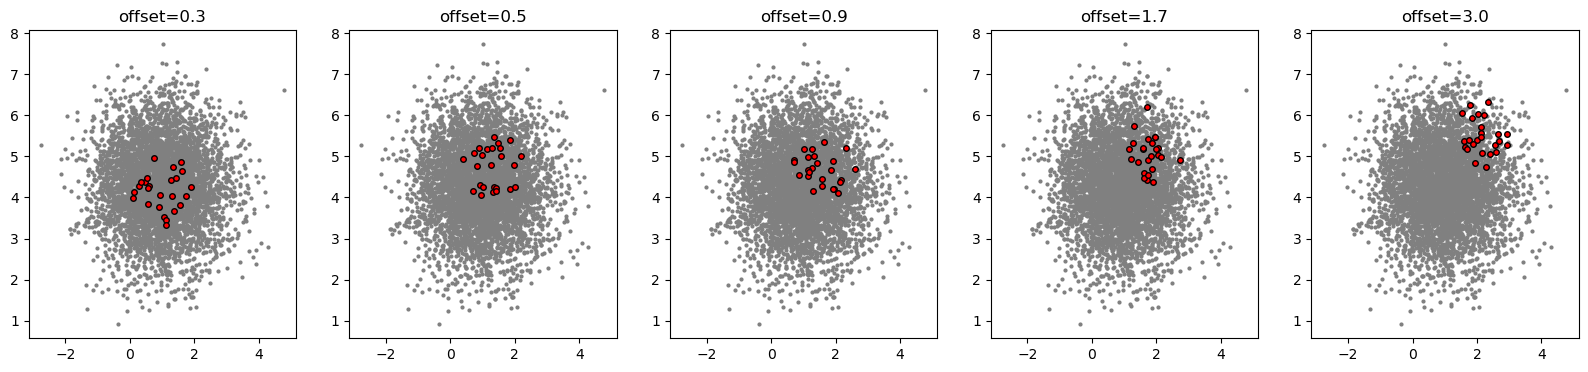

In [24]:
plt.figure(figsize=(20, 4))
i_plots = np.floor(np.linspace(0, n_tests-1, 5)).astype(int)
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.plot(coords[:,0], coords[:,1], '.', markersize=4, color='gray')
    # sns.kdeplot(x=coords[:,0], y=coords[:,1], levels=7, color='k')
    plt.plot(coords[genes[:,i_plots[i]]>0,0], 
             coords[genes[:,i_plots[i]]>0,1], 
             'o',
             markersize=4,
             markerfacecolor='r', 
             markeredgecolor='k')
    plt.title(f'offset={radii[i_plots[i]]:.1f}')
plt.show()
    

In [25]:
%%time
reset_seeds(SEED)
m = LOCAT(create_anndata(genes.astype(np.float64)), coords.astype(np.float64), 20, show_progress=True, n_bootstrap_inits=100, knn=adata.obsp["connectivities"])
m.background_pdf(force_refresh=True)

sres = {
    'full': m.gmm_scan(
        zscore_thresh=-np.inf,
        max_freq=1.0,
        rc_lambda_values=np.linspace(1.0, 2.0, 8),
        include_depletion_scan=True,
    ),
    'local': m.gmm_local_scan(zscore_thresh=-np.inf, max_freq=1.0),
    'llr': m.gmm_loglikelihoodtest(max_freq=1.0),
    'lpval': m.gmm_local_pvalue(),
}

locat_df = pd.DataFrame({gene: res._asdict() for gene, res in sres["full"].items()}).T
locat_df.index.name = "gene"


2026-03-17 16:45:05.244 | INFO     | locat.locat:background_pdf:427 - fitting background PDF
2026-03-17 16:45:05.247 | INFO     | locat.locat:background_n_components_init:197 - Estimating number of GMM components
estimating BIC for 5000 cells:   0%|                                           | 0/9 [00:00<?, ?it/s]2026-03-17 16:45:05.251 | INFO     | locat.locat:min_dist:135 - recomputing min cell-cell distance
2026-03-17 16:45:05.252 | INFO     | locat.locat:cell_dist:127 - recomputing cell-cell distance
estimating BIC for 70 cells: 100%|██████████████████████████████████| 30/30 [00:00<00:00, 245.94it/s]
2026-03-17 16:45:06.488 | INFO     | locat.locat:background_pdf:439 - Using 1 components
fitting background: 100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 249.77it/s]
null distribution parameters (perm. pseudo-genes): 100%|███████████████| 7/7 [00:50<00:00,  7.17s/it]
scanning genes: 100%|██████████████████████████████████████████████| 200/200 [03:00<00:00,  1.11

CPU times: user 18min 25s, sys: 59min 56s, total: 1h 18min 21s
Wall time: 4min 4s


In [26]:
# LOCAT native p-values are used directly via locat_df["pval"] in this repro notebook.


In [27]:
# No permissive p_final recomputation is applied here.


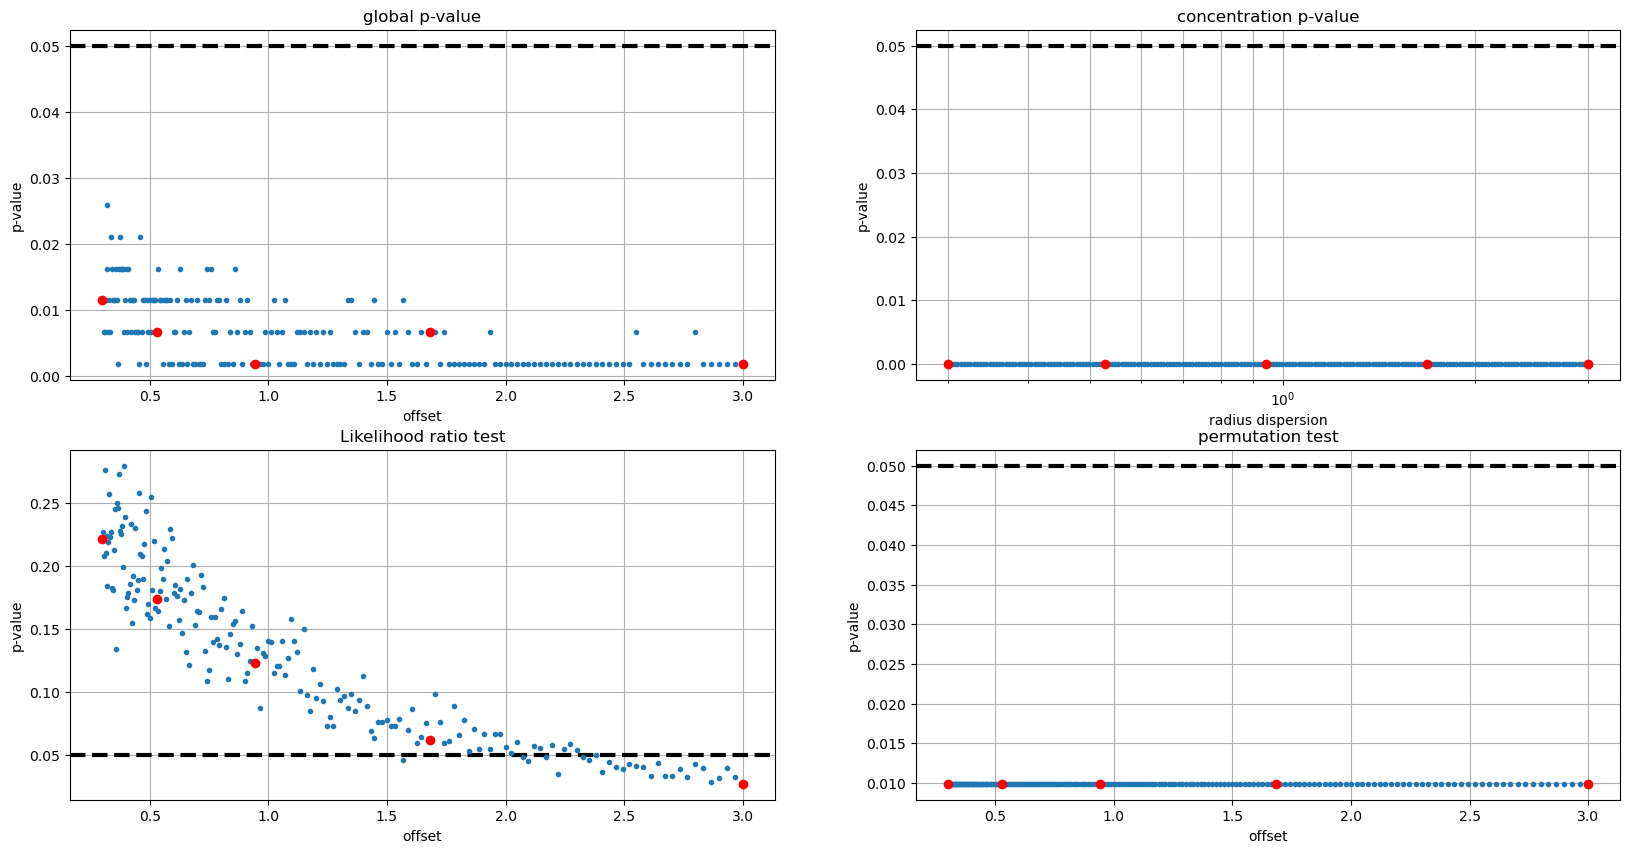

In [28]:
plt.figure(figsize=(20, 10))

plt.subplot(221)
plt.plot(
    radii,
    locat_df['pval'].values,
    '.')
plt.plot(
    radii[i_plots],
    locat_df['pval'].values[i_plots],
    'ro')
# plt.gca().set_xscale('log')
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.ylabel('p-value')
plt.xlabel('offset')
plt.title('global p-value')
plt.grid(which='both')

#plt.subplot(222)
#plt.plot(
#    radii,
#    pd.Series({i: np.min(row['local_pvalue']) for i, row in pd.DataFrame(sres['local']).T.iterrows()}).values,
#    '.')
#plt.plot(
#    radii[i_plots],
#    pd.Series({i: np.min(row['local_pvalue']) for i, row in pd.DataFrame(sres['local']).T.iterrows()}).values[i_plots],
#    'ro')
## plt.gca().set_xscale('log')
#plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
#plt.ylabel('minimum local p-value')
#plt.xlabel('offset')
#plt.title('Local p-value')
#plt.grid(which='both')

plt.subplot(222)
plt.plot(
    radii,
    locat_df['concentration_pval'].values,
    '.')
plt.plot(
    radii[i_plots],
    locat_df['concentration_pval'].values[i_plots],
    'ro')
plt.gca().set_xscale('log')
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.ylabel('p-value')
plt.xlabel('radius dispersion')
plt.title('concentration p-value')

plt.grid(which='both')

plt.subplot(223)
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.plot(
    radii,
    pd.DataFrame(sres['llr']).T['llratio_pvalue'].values,
    '.')
plt.plot(
    radii[i_plots],
    pd.DataFrame(sres['llr']).T['llratio_pvalue'].values[i_plots],
    'ro')
# plt.gca().set_xscale('log')
plt.ylabel('p-value')
plt.xlabel('offset')
plt.title('Likelihood ratio test')
plt.grid(which='both')

plt.subplot(224)
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.plot(
    radii,
    pd.DataFrame(sres['lpval']).T['zscore_pvalue'].values,
    '.')
plt.plot(
    radii[i_plots],
    pd.DataFrame(sres['lpval']).T['zscore_pvalue'].values[i_plots],
    'ro')
# plt.gca().set_xscale('log')
plt.ylabel('p-value')
plt.xlabel('offset')
plt.title('permutation test')
plt.grid(which='both')

plt.show()

# Multi loci and jitter

In [29]:
from sklearn.cluster import KMeans
from scipy.stats import rankdata

In [30]:
kclust = KMeans(n_clusters=8, random_state=1)
clusts = kclust.fit_predict(rankdata(coords, axis=0))

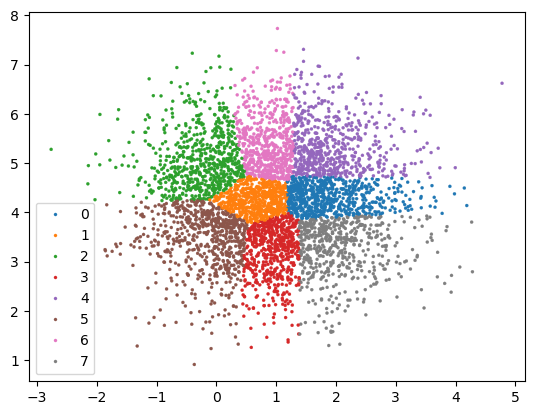

In [31]:
sns.scatterplot(
    x=coords[:,0], 
    y=coords[:,1],
    hue=clusts,
    palette='tab10',
    s=5,
    edgecolor=None)
plt.show()

In [32]:
reset_seeds(SEED)
# corona

from sklearn.neighbors import NearestNeighbors

def find_closest_points(points, n, supersample, clusts, sel_clusts=(2, 7)):
    N = points.shape[0]  # Number of points
    # Randomly select n unique indices from N
    random_indices = np.array([
        np.random.choice(np.flatnonzero(clusts==sel_clust), size=1, replace=False)
        for sel_clust in sel_clusts])
    
    # Fit NearestNeighbors model
    nbrs = NearestNeighbors(n_neighbors=supersample*30, algorithm='auto').fit(points)
    
    # Find 25 closest points for each selected point
    closest_points_indices = []
    for idx in random_indices:
        distances, indices = nbrs.kneighbors(points[idx].reshape(1, -1))
        closest_points_indices.extend(indices.tolist()[0])
    return np.unique(np.random.choice(closest_points_indices, size=(30*n, ), replace=False)).astype(int)
    

ns = np.ceil(np.arange(1, 1001)/10).astype(int)[::10]
n_tests = len(ns)
print(n_tests)
genes = np.zeros(shape=(coords.shape[0], n_tests))

for i, n in enumerate(ns):
    i_genes = find_closest_points(coords, 2, supersample=n, clusts=clusts)
    genes[i_genes, i] = 1

100


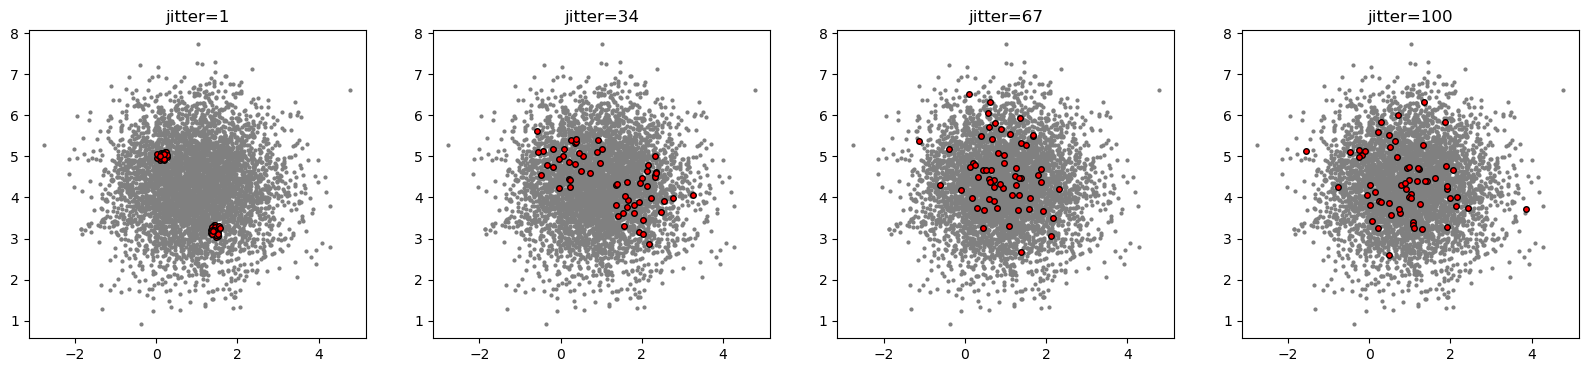

In [33]:
plt.figure(figsize=(20, 4))
i_plots = np.floor(np.linspace(0, n_tests-1, 4)).astype(int)
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.plot(coords[:,0], coords[:,1], '.', markersize=4, color='gray')
    # sns.kdeplot(x=coords[:,0], y=coords[:,1], levels=7, color='k')
    plt.plot(coords[genes[:,i_plots[i]]>0,0], 
             coords[genes[:,i_plots[i]]>0,1], 
             'o',
             markersize=4,
             markerfacecolor='r', 
             markeredgecolor='k')
    plt.title(f'jitter={ns[i_plots[i]]:.0f}')
plt.show()


In [34]:
%%time
reset_seeds(SEED)
m = LOCAT(create_anndata(genes.astype(np.float64)), coords.astype(np.float64), 20, show_progress=True, n_bootstrap_inits=100, knn=adata.obsp["connectivities"])
m.background_pdf(force_refresh=True)

sres = {
    'full': m.gmm_scan(
        zscore_thresh=-np.inf,
        max_freq=1.0,
        rc_lambda_values=np.linspace(1.0, 2.0, 8),
        include_depletion_scan=True,
    ),
    'local': m.gmm_local_scan(zscore_thresh=-np.inf, max_freq=1.0),
    'llr': m.gmm_loglikelihoodtest(max_freq=1.0),
    'lpval': m.gmm_local_pvalue(),
}

locat_df = pd.DataFrame({gene: res._asdict() for gene, res in sres["full"].items()}).T
locat_df.index.name = "gene"


2026-03-17 16:51:12.246 | INFO     | locat.locat:background_pdf:427 - fitting background PDF
2026-03-17 16:51:12.248 | INFO     | locat.locat:background_n_components_init:197 - Estimating number of GMM components
estimating BIC for 5000 cells:   0%|                                           | 0/9 [00:00<?, ?it/s]2026-03-17 16:51:12.251 | INFO     | locat.locat:min_dist:135 - recomputing min cell-cell distance
2026-03-17 16:51:12.251 | INFO     | locat.locat:cell_dist:127 - recomputing cell-cell distance
estimating BIC for 70 cells: 100%|██████████████████████████████████| 30/30 [00:00<00:00, 122.06it/s]
2026-03-17 16:51:14.452 | INFO     | locat.locat:background_pdf:439 - Using 1 components
fitting background: 100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 120.88it/s]
null distribution parameters (perm. pseudo-genes): 100%|███████████████| 7/7 [01:27<00:00, 12.57s/it]
scanning genes: 100%|██████████████████████████████████████████████| 100/100 [01:02<00:00,  1.60

CPU times: user 8min 33s, sys: 29min 20s, total: 37min 54s
Wall time: 2min 38s


In [35]:
# LOCAT native p-values are used directly via locat_df["pval"] in this repro notebook.


In [36]:
# No permissive p_final recomputation is applied here.


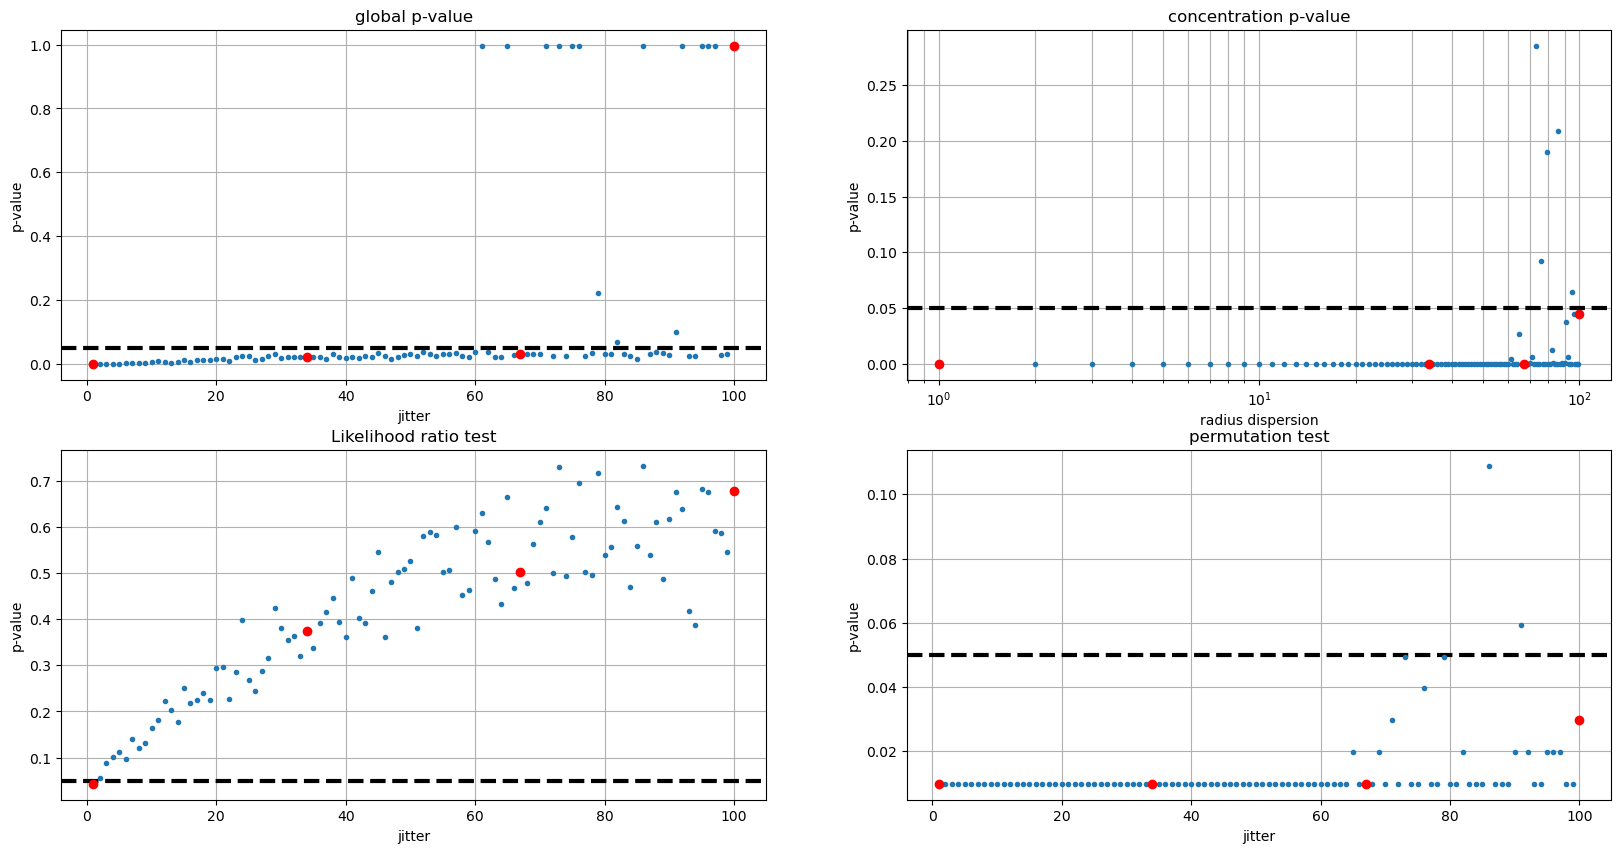

In [37]:
plt.figure(figsize=(20, 10))

plt.subplot(221)
plt.plot(
    ns,
    locat_df['pval'].values,
    '.')
plt.plot(
    ns[i_plots],
    locat_df['pval'].values[i_plots],
    'ro')
# plt.gca().set_xscale('log')
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.ylabel('p-value')
plt.xlabel('jitter')
plt.title('global p-value')
plt.grid(which='both')


plt.subplot(222)
plt.plot(
    ns,
    locat_df['concentration_pval'].values,
    '.')
plt.plot(
    ns[i_plots],
    locat_df['concentration_pval'].values[i_plots],
    'ro')
plt.gca().set_xscale('log')
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.ylabel('p-value')
plt.xlabel('radius dispersion')
plt.title('concentration p-value')

plt.grid(which='both')

plt.subplot(223)
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.plot(
    ns,
    pd.DataFrame(sres['llr']).T['llratio_pvalue'].values,
    '.')
plt.plot(
    ns[i_plots],
    pd.DataFrame(sres['llr']).T['llratio_pvalue'].values[i_plots],
    'ro')
# plt.gca().set_xscale('log')
plt.ylabel('p-value')
plt.xlabel('jitter')
plt.title('Likelihood ratio test')
plt.grid(which='both')

plt.subplot(224)
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.plot(
    ns,
    pd.DataFrame(sres['lpval']).T['zscore_pvalue'].values,
    '.')
plt.plot(
    ns[i_plots],
    pd.DataFrame(sres['lpval']).T['zscore_pvalue'].values[i_plots],
    'ro')
# plt.gca().set_xscale('log')
plt.ylabel('p-value')
plt.xlabel('jitter')
plt.title('permutation test')
plt.grid(which='both')

plt.show()

# Sample size

In [38]:
np.sqrt(np.sqrt(250))

3.976353643835253

In [39]:
reset_seeds(SEED)
# power

n_tests = 100
ns = np.linspace(25, 251, n_tests).astype(int)
genes = np.zeros(shape=(coords.shape[0], n_tests))
for i, s in enumerate(ns):
    i_sel = np.flatnonzero( np.sqrt(np.sum((coords - (centers[0,:] + 0))**2, axis=1)) < (0.2*np.sqrt(s/2)) )
    if len(i_sel)>=n:
        i_genes = np.random.choice(i_sel, s, replace=False)
        genes[i_genes, i] = 1
    else:
        # i_sel = np.flatnonzero( np.sqrt(np.sum((coords - (centers[0,:] + 0))**2, axis=1)) < (0.4 * np.sqrt(s/2)) )
        if len(i_sel)>=n:
            i_genes = np.random.choice(i_sel, s, replace=False)
            genes[i_genes, i] = 1
        else:
            print(f'{i} {s} {len(i_sel)}')


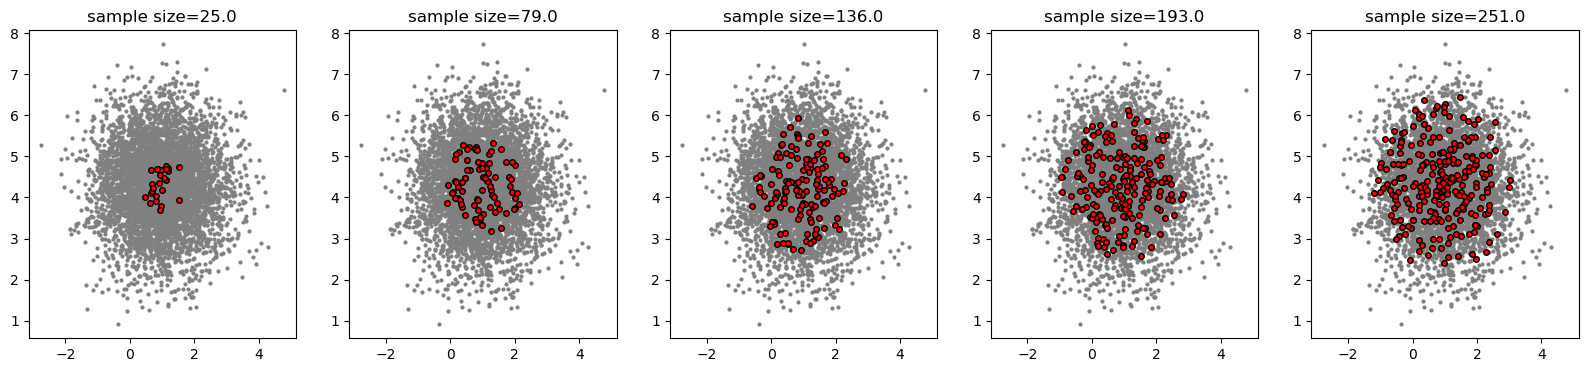

In [40]:
plt.figure(figsize=(20, 4))
i_plots = np.floor(np.linspace(0, n_tests-1, 5)).astype(int)
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.plot(coords[:,0], coords[:,1], '.', markersize=4, color='gray')
    #sns.kdeplot(x=coords[:,0], y=coords[:,1], levels=7, color='k')
    plt.plot(coords[genes[:,i_plots[i]]>0,0], 
             coords[genes[:,i_plots[i]]>0,1], 
             'o',
             markersize=4,
             markerfacecolor='r', 
             markeredgecolor='k')
    plt.title(f'sample size={ns[i_plots[i]]:.1f}')
plt.show()
    

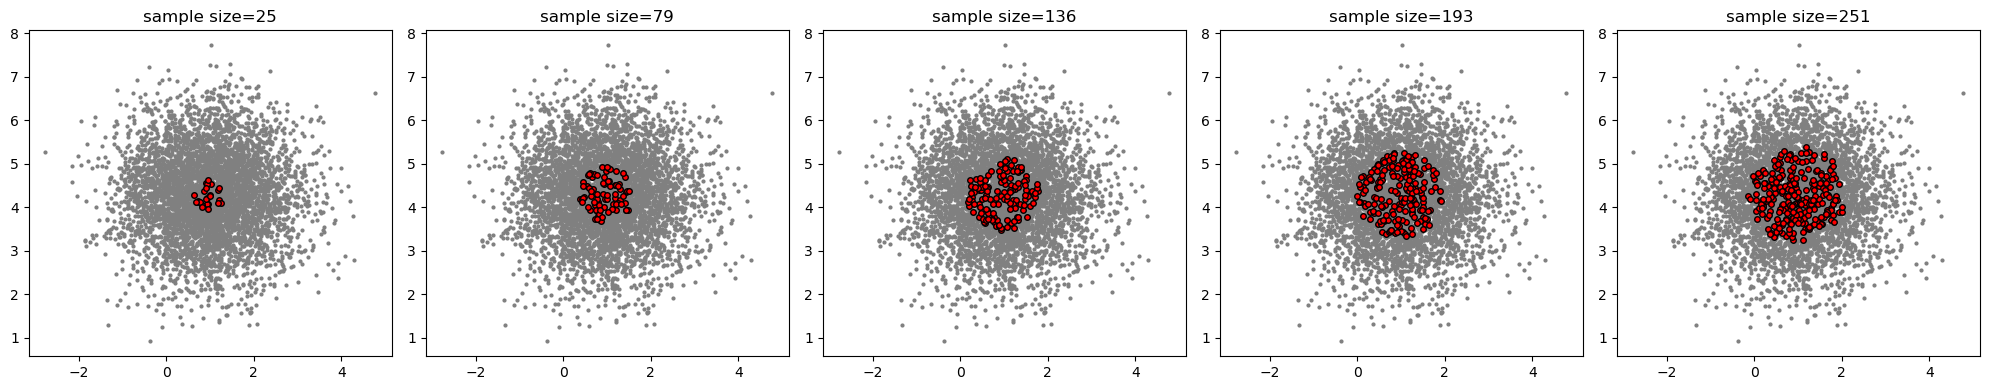

In [46]:
reset_seeds(SEED)
import numpy as np
import matplotlib.pyplot as plt

# power
n_tests = 100
ns = np.linspace(25, 251, n_tests).astype(int)

genes = np.zeros(shape=(coords.shape[0], n_tests), dtype=np.int8)

beta = 0.5          
r0 = 0.1             
s_ref = 25           

for i, s in enumerate(ns):
    r_ref = r0 * np.sqrt(s_ref / 2)
    r = r_ref * (s / s_ref) ** beta

    i_sel = np.flatnonzero(
        np.sqrt(np.sum((coords - centers[0, :])**2, axis=1)) < r
    )

    if len(i_sel) >= s:
        i_genes = np.random.choice(i_sel, s, replace=False)
        genes[i_genes, i] = 1
    else:
        print(f"{i} {s} {len(i_sel)}")  # not enough cells in radius

plt.figure(figsize=(20, 4))
i_plots = np.floor(np.linspace(0, n_tests - 1, 5)).astype(int)

for j in range(5):
    plt.subplot(1, 5, j + 1)
    plt.plot(coords[:, 0], coords[:, 1], ".", markersize=4, color="gray")

    sel = genes[:, i_plots[j]] > 0
    plt.plot(
        coords[sel, 0],
        coords[sel, 1],
        "o",
        markersize=4,
        markerfacecolor="r",
        markeredgecolor="k",
    )
    plt.title(f"sample size={ns[i_plots[j]]:.0f}")

plt.tight_layout()
plt.show()


In [47]:
%%time
reset_seeds(SEED)
m = LOCAT(create_anndata(genes.astype(np.float64)), coords.astype(np.float64), 20, show_progress=True, n_bootstrap_inits=100, knn=adata.obsp["connectivities"])
m.background_pdf(force_refresh=True)

sres = {
    'full': m.gmm_scan(
        zscore_thresh=-np.inf,
        max_freq=1.0,
        rc_lambda_values=np.linspace(1.0, 2.0, 8),
        include_depletion_scan=True,
    ),
    'local': m.gmm_local_scan(zscore_thresh=-np.inf, max_freq=1.0),
    'llr': m.gmm_loglikelihoodtest(max_freq=1.0),
    'lpval': m.gmm_local_pvalue(),
}

locat_df = pd.DataFrame({gene: res._asdict() for gene, res in sres["full"].items()}).T
locat_df.index.name = "gene"


2026-03-17 17:07:10.312 | INFO     | locat.locat:background_pdf:427 - fitting background PDF
2026-03-17 17:07:10.315 | INFO     | locat.locat:background_n_components_init:197 - Estimating number of GMM components
estimating BIC for 5000 cells:   0%|                                           | 0/9 [00:00<?, ?it/s]2026-03-17 17:07:10.320 | INFO     | locat.locat:min_dist:135 - recomputing min cell-cell distance
2026-03-17 17:07:10.320 | INFO     | locat.locat:cell_dist:127 - recomputing cell-cell distance
estimating BIC for 70 cells: 100%|███████████████████████████████████| 30/30 [00:00<00:00, 98.81it/s]
2026-03-17 17:07:18.408 | INFO     | locat.locat:background_pdf:439 - Using 1 components
fitting background: 100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 157.78it/s]
null distribution parameters (perm. pseudo-genes): 100%|███████████████| 7/7 [08:37<00:00, 73.91s/it]
scanning genes: 100%|██████████████████████████████████████████████| 100/100 [01:13<00:00,  1.37

CPU times: user 9min 39s, sys: 42min 48s, total: 52min 28s
Wall time: 10min 6s


In [48]:
# LOCAT native p-values are used directly via locat_df["pval"] in this repro notebook.


In [49]:
# No permissive p_final recomputation is applied here.


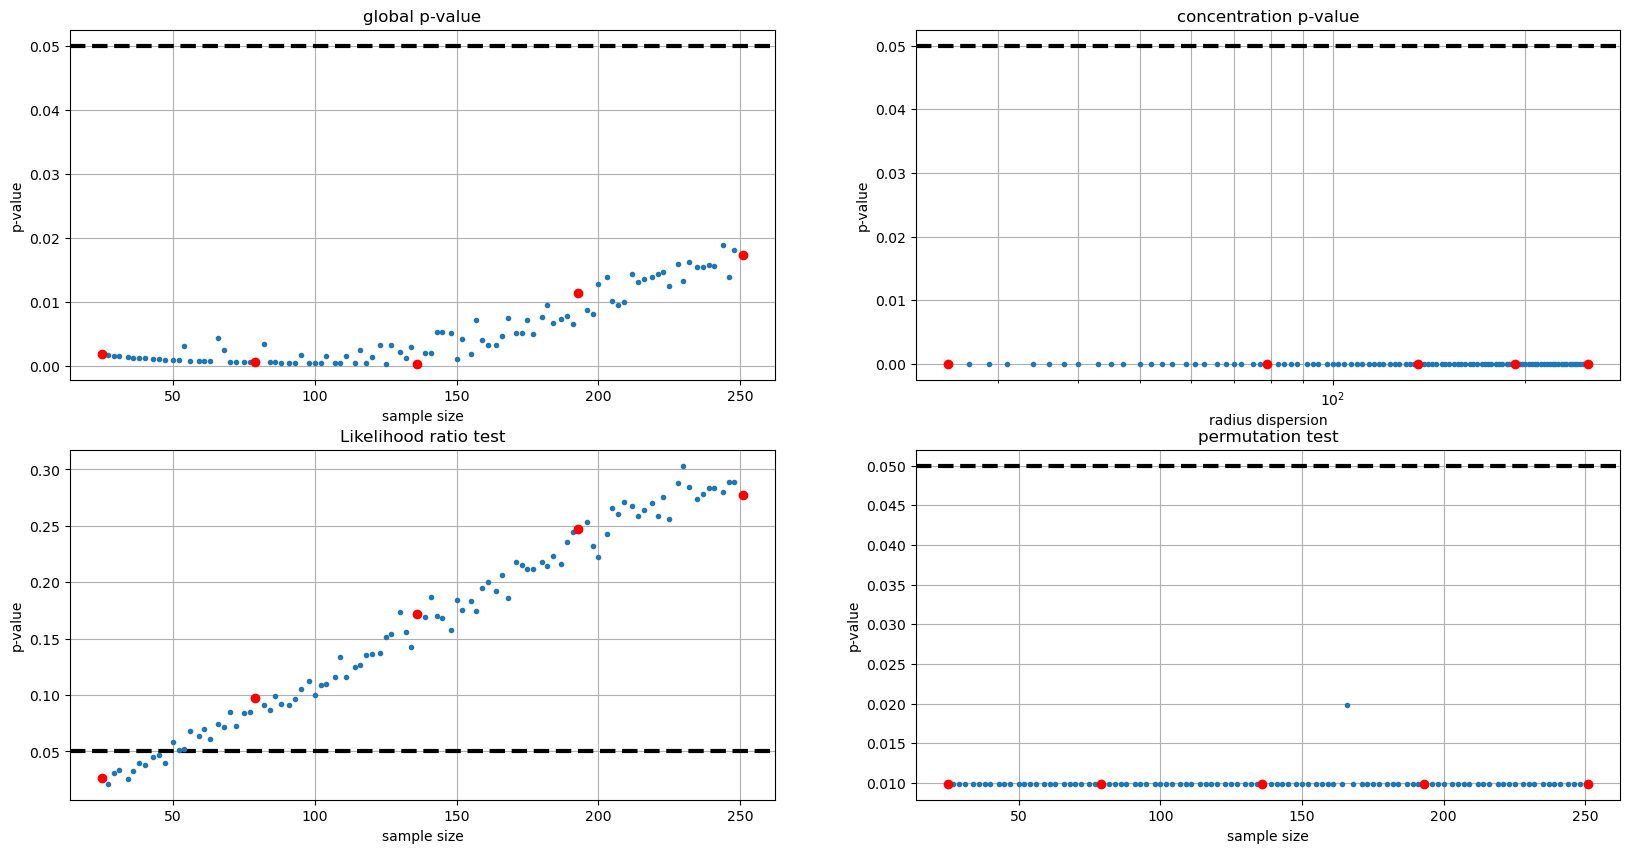

In [50]:
plt.figure(figsize=(20, 10))

plt.subplot(221)
plt.plot(
    ns,
    locat_df['pval'].values,
    '.')
plt.plot(
    ns[i_plots],
    locat_df['pval'].values[i_plots],
    'ro')
# plt.gca().set_xscale('log')
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.ylabel('p-value')
plt.xlabel('sample size')
plt.title('global p-value')
plt.grid(which='both')


plt.subplot(222)
plt.plot(
    ns,
    locat_df['concentration_pval'].values,
    '.')
plt.plot(
    ns[i_plots],
    locat_df['concentration_pval'].values[i_plots],
    'ro')
plt.gca().set_xscale('log')
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.ylabel('p-value')
plt.xlabel('radius dispersion')
plt.title('concentration p-value')

plt.grid(which='both')

plt.subplot(223)
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.plot(
    ns,
    pd.DataFrame(sres['llr']).T['llratio_pvalue'].values,
    '.')
plt.plot(
    ns[i_plots],
    pd.DataFrame(sres['llr']).T['llratio_pvalue'].values[i_plots],
    'ro')
# plt.gca().set_xscale('log')
plt.ylabel('p-value')
plt.xlabel('sample size')
plt.title('Likelihood ratio test')
plt.grid(which='both')

plt.subplot(224)
plt.axhline(0.05, color='k', linestyle='--', linewidth=3)
plt.plot(
    ns,
    pd.DataFrame(sres['lpval']).T['zscore_pvalue'].values,
    '.')
plt.plot(
    ns[i_plots],
    pd.DataFrame(sres['lpval']).T['zscore_pvalue'].values[i_plots],
    'ro')
# plt.gca().set_xscale('log')
plt.ylabel('p-value')
plt.xlabel('sample size')
plt.title('permutation test')
plt.grid(which='both')

plt.show()